In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm


%autoreload 2


In [2]:
from CRYOtools.util import return_obs_info, get_slit_coords, print_exposure, get_spectral_coords
from CRYOtools.io import get_all_head, get_fits_data, load_asdf, restore_slit_coords
from CRYOtools.plotting import plot_slit_locs, aia_context_plot, plot_line_example, quick_plot_emission
from CRYOtools.fit import fit_data
from CRYOtools.io import write_model_results 

# Reading in data

The run the following you will need to have downloaded the Cryo-NIRSP data set with identifier pid_3_88/UKCFYO.

A quick check of the data set information:

In [3]:
path = '/Users/richardmorton/analysis/ext_data/DKIST2/cycle3/pid_3_88/UKCFYO/'
ds = load_asdf(path)

Dataset data shape: (4, 21, 1919, 902)


/Users/richardmorton/anaconda3/envs/sunpy_env2/lib/python3.10/site-packages/asdf/_asdf.py:294: AsdfPackageVersionWarning: File 'file:///Users/richardmorton/analysis/ext_data/DKIST2/cycle3/pid_3_88/UKCFYO/CRYO-NIRSP_L1_20250322T192131_UKCFYO_metadata.asdf' was created with extension URI 'asdf://dkist.nso.edu/dkist/extensions/dkist-1.4.0' (from package dkist==1.12.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)
/Users/richardmorton/anaconda3/envs/sunpy_env2/lib/python3.10/site-packages/asdf/_asdf.py:310: AsdfPackageVersionWarning: File 'file:///Users/richardmorton/analysis/ext_data/DKIST2/cycle3/pid_3_88/UKCFYO/CRYO-NIRSP_L1_20250322T192131_UKCFYO_metadata.asdf' was created with extension URI 'asdf://dkist.nso.edu/dkist/extensions/dkist-wcs-1.2.0' (from package dkist==1.12.0), but older package (dkist==1.9.2) is installed.
  warnings.warn(msg, AsdfPackageVersionWarning)


Read in the header files.

In [4]:
hdrs = get_all_head(path)

Getting headers: 100%|██████████████████████████| 84/84 [00:03<00:00, 24.08it/s]


Get some observation info from the headers.

Shows the number of scan steps, the number of exposures at each step, the number of wavelength pixels and the number of locations along the slit.

In [5]:
n_scan_steps, n_meas_at_step, n_wv, n_along_slit = return_obs_info(hdrs)
print(n_scan_steps, n_meas_at_step, n_wv, n_along_slit)

CNP1DSS =                  2.5 / PriScan1stDirStepSize                          END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

Read in and convert the coordinate information. Converted data are saved to disk as they are useful and take some time to convert.

In [107]:
res = get_slit_coords(hdrs, output_dir=path, cpu_max=1)
hpxy_coords, time_coords = res

Processing:   0%|                                    | 0/84 [00:01<?, ?it/s]


WCS Keywords

Number of WCS axes: 3
CTYPE : 'AWAV-GRA' 'HPLT-TAN' 'HPLN-TAN' 
CRVAL : 1.0745250947560513e-06 0.1039088481054217 -0.2824178046068014 
CRPIX : 452.0 959.0 194.16666666666669 
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0 
PC2_1 PC2_2 PC2_3  : 0.0 0.9389048883791841 0.3521577488543203 
PC3_1 PC3_2 PC3_3  : 0.0 0.34568863920966303 -0.9414840950401404 
CDELT : 4.373911124634653e-12 3.3333333333333335e-05 3.3333333333333335e-05 
NAXIS : 902  1919  1
<class 'astropy.units.quantity.Quantity'>
<class 'astropy.units.quantity.Quantity'>
WCS Keywords

Number of WCS axes: 3
CTYPE : 'AWAV-GRA' 'HPLT-TAN' 'HPLN-TAN' 
CRVAL : 1.0745250947560513e-06 0.10390886563946478 -0.2824172355374953 
CRPIX : 452.0 959.0 174.75000000000003 
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0 
PC2_1 PC2_2 PC2_3  : 0.0 0.9389040772392753 0.352903016425942 
PC3_1 PC3_2 PC3_3  : 0.0 0.3456908422918096 -0.9418261708367838 
CDELT : 4.373911124634653e-12 3.3333333333333335e-05 3.3333333333333335e-05 
NAXIS : 902  1919  1
<class 'astropy

AttributeError: 'Quantity' object has no 'Tx' member

In [10]:
spec_coords = get_spectral_coords(hdrs, output_dir=path)

Directory already exists: /Users/richardmorton/analysis/DKIST/cycle3/pid_3_88/UKCFYO/
Spectral Coordinates Shape: (902,)


Restore the coordinate information. No need for this step if you just done the conversion.

In [5]:
res = restore_slit_coords(path)
hpxy_coords, time_coords, spec_coords = res

Examine the spatial location of the slit.

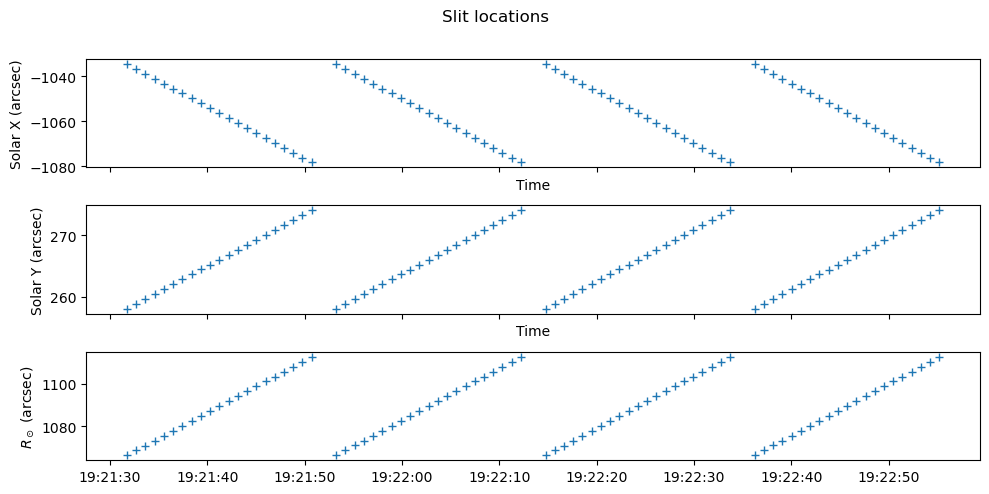

In [6]:
plot_slit_locs(hpxy_coords, time_coords)

Can also pull the information about the data used to build each exposure.

In [7]:
print_exposure(hdrs)

XPOSURE    [ms] FPAExposureTime      725.0 
TEXPOSUR   [ms] CamExposureTime      90.625 
CAM_FPS    [Hz] CamFrameRate         1.10114414161806 
CNNSCI     CameraNumScienceFrames    8 
CNNNDR     CameraNumNDRs             10 
CNMODNST   ModulatorNumStates        1 
CNNMEAS    CameraNumMeasAtSamePos    1 
Time between ramps (i.e. triggers): 908.14632 msec
Times between first and last trigger: 0:01:23.462109


Now show the location of the Cryo-NIRSP on an SDO/AIA image.

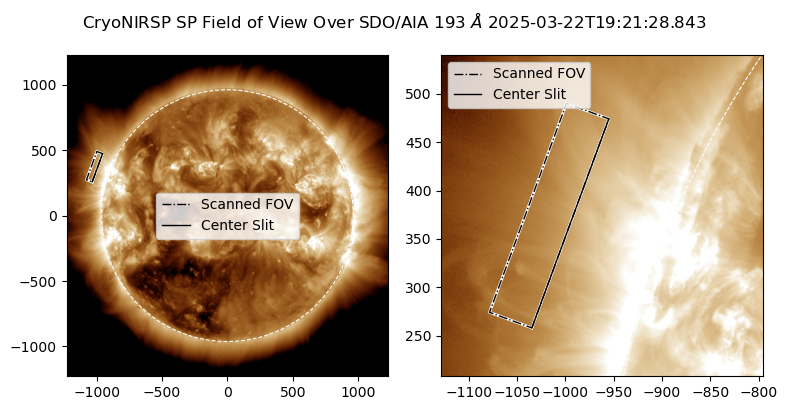

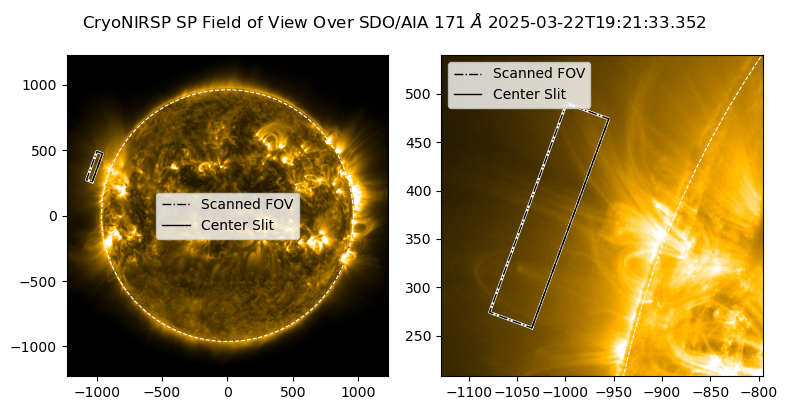

In [13]:
aia_context_plot(hdrs, hpxy_coords, n_scan_steps, flip_image=True)

In [8]:
data, files = get_fits_data(path)

Getting headers: 100%|██████████████████████████| 84/84 [00:01<00:00, 53.17it/s]


CNP1DSS: 2.5
CNP1DNSP: 21
CNP2DSS: 0.0
CNP2DNSP: 4
Defined data set shape to load:  (1, 84, 1, 1919, 902)


Reading in data: 100%|██████████████████████████| 84/84 [00:14<00:00,  5.71it/s]


Multiple exposures co-added and averaged.


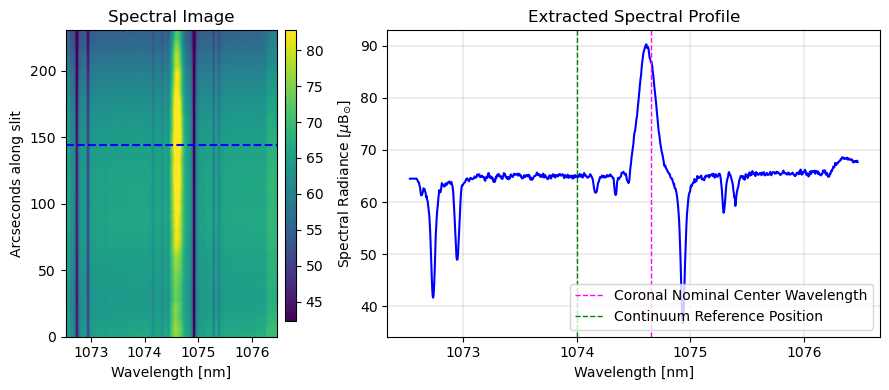

In [9]:
plot_line_example(data, spec_coords, hpxy_coords, hdrs, scan_step=30)

We can do a quick plot of line emission by integrating over wavelength around line. In this example there are 4 repitions of the raster.

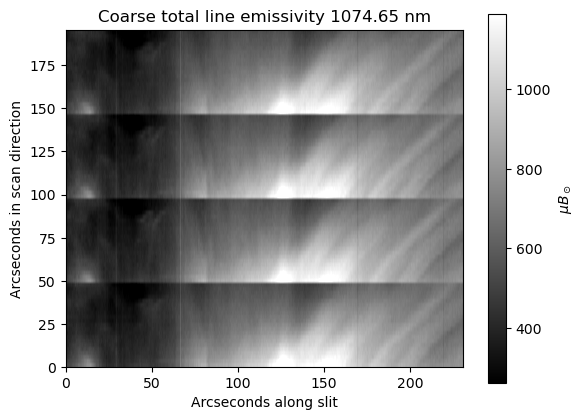

In [10]:
quick_plot_emission(data, spec_coords, hpxy_coords, hdrs)

Fit a single slits worth of data

In [21]:
test = fit_data(data[0,-1,0], spec_coords)
wgts = np.ones(test.n_wv)
wgts[spec_coords > 1076] = 0 
wgts[spec_coords < 1073.5] = 0 
res = test.fit_slit(use_tqdm=True, wgts=wgts)
#write_model_results(path, files[-1], res)

Processing:   0%|          | 0/1919 [00:00<?, ?it/s]

In [11]:
modelled = [test.build_model(r.x) for r in res]

In [12]:
modelled=np.array(modelled)

In [22]:
from CRYOtools.plotting import plot_spectrogram_wf

1074.65
1074.65
1074.65


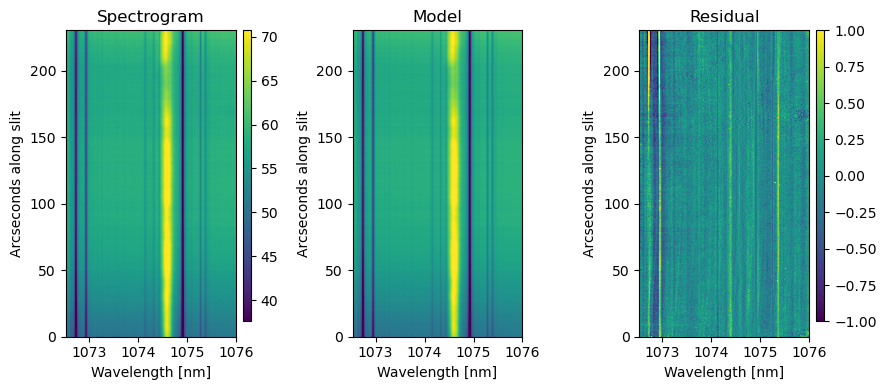

In [26]:
plot_spectrogram_wf(data[0,-1,0], modelled, spec_coords, hpxy_coords, hdrs, trim_end=True)
#plt.savefig('example_spectrogram.png', dpi=300)

Now fit all the slit data. Uses parallel processing. For two cpus, this took an hour to run. Bear in mind this is only 84 exposures!

In [21]:

def work(data, spec_coords, wgts, path, file):
    test = fit_data(data, spec_coords)
    res = test.fit_slit(use_tqdm=True, wgts=wgts)
    write_model_results(path, file, res)
    return None

ncpus = 2
tasks = [(dat,spec_coords, wgts, path, file) for dat, file in zip(data[0,:,0],files)]
with ThreadPoolExecutor(max_workers=ncpus) as executor:
        results = list(tqdm(executor.map(work, *zip(*tasks)), total=len(files), desc="Processing"))

Processing:   0%|                                                                       | 0/83 [00:00<?, ?it/s]

Processing:   0%|          | 0/1919 [00:00<?, ?it/s]

Processing:   0%|          | 0/1919 [00:00<?, ?it/s]

Processing:   1%|▋                                                           | 1/83 [01:45<2:24:20, 105.61s/it]

Processing:   0%|          | 0/1919 [00:00<?, ?it/s]

...

Processing:  96%|███████████████████████████████████████████████████████████▊  | 80/83 [58:57<01:43, 34.64s/it]

Processing:   0%|          | 0/1919 [00:00<?, ?it/s]

Processing:  98%|██████████████████████████████████████████████████████████▌ | 81/83 [1:00:13<01:34, 47.14s/it]

Processing:   0%|          | 0/1919 [00:00<?, ?it/s]

Processing: 100%|████████████████████████████████████████████████████████████| 83/83 [1:01:17<00:00, 44.31s/it]


We can now bring in the results from the fitted line profiles

In [11]:
from CRYOtools.fit import pull_fit_res
raster_res, metrics = pull_fit_res(path)

Getting fit data:   0%|          | 0/84 [00:00<?, ?it/s]

And plot all the fitted parameters

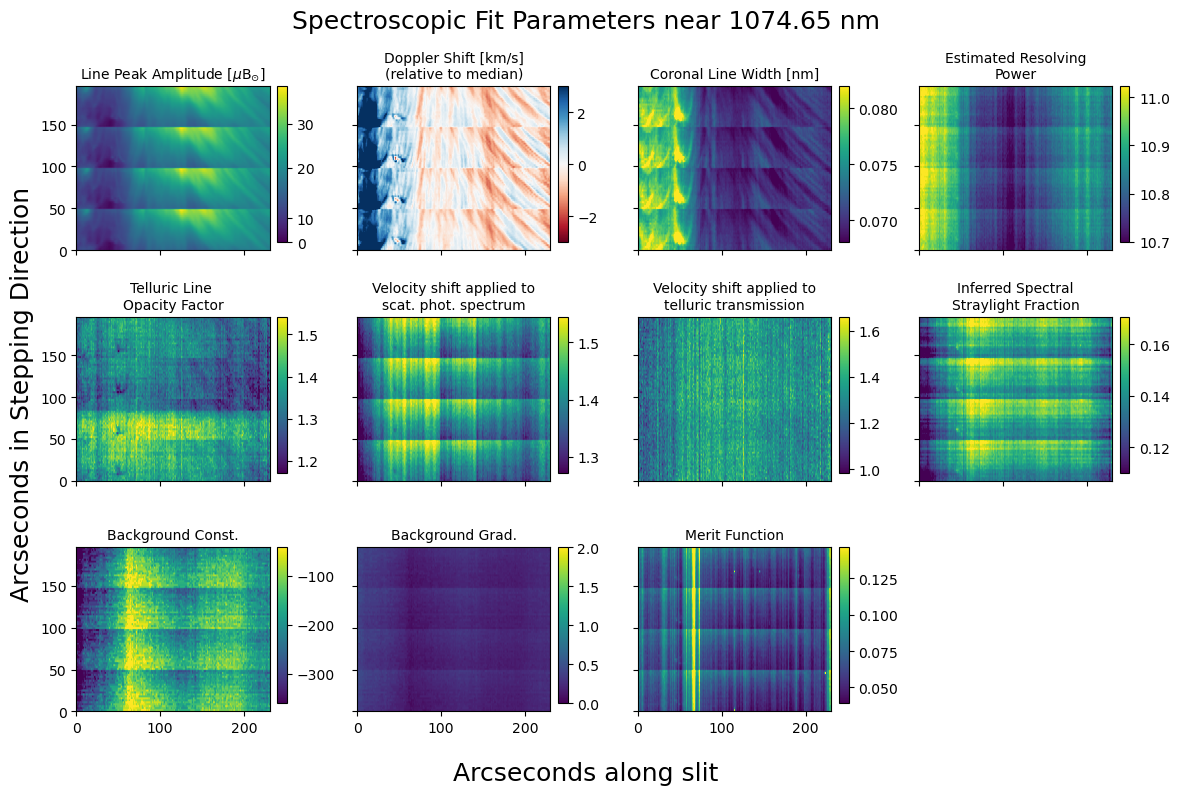

In [13]:
from CRYOtools.plotting import plot_all_params_scan

plot_all_params_scan(raster_res, metrics, spec_coords, hpxy_coords, hdrs)

Or just focus on the coronal values

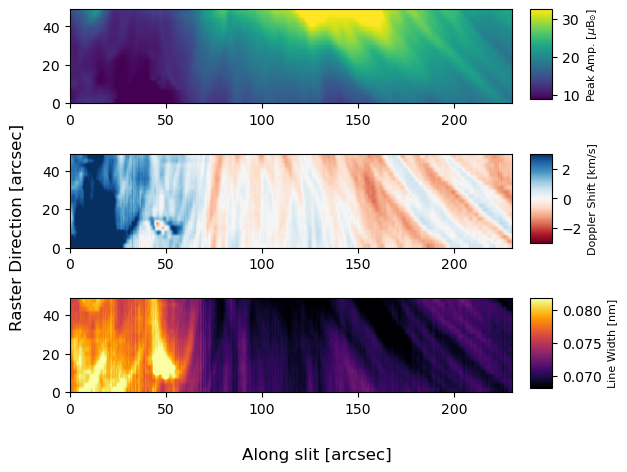

In [66]:
from CRYOtools.plotting import plot_coronal_params

raster_fold = [m.reshape(4,21,1919).mean(axis=0) for m in raster_res]

plot_coronal_params(raster_fold, hpxy_coords, hdrs, spec_coords, fold=4)

# The sit and stare data

The following is an example for sit and stare data, it assumes you have the data set pid_3_88/KJSDTD.

The same code used above should work for both types of data set.

In [14]:
# fit data
path = '/Users/richardmorton/analysis/DKIST/cycle3/pid_3_88/KJSDTD/'
ds = load_asdf(path)

Dataset data shape: (1, 3800, 1919, 902)


/Users/richardmorton/anaconda3/envs/sunpy_env2/lib/python3.10/site-packages/asdf/_asdf.py:294: AsdfPackageVersionWarning: File 'file:///Users/richardmorton/analysis/DKIST/cycle3/pid_3_88/KJSDTD/CRYO-NIRSP_L1_20250322T192316_KJSDTD_metadata.asdf' was created with extension URI 'asdf://dkist.nso.edu/dkist/extensions/dkist-1.4.0' (from package dkist==1.12.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)
/Users/richardmorton/anaconda3/envs/sunpy_env2/lib/python3.10/site-packages/asdf/_asdf.py:310: AsdfPackageVersionWarning: File 'file:///Users/richardmorton/analysis/DKIST/cycle3/pid_3_88/KJSDTD/CRYO-NIRSP_L1_20250322T192316_KJSDTD_metadata.asdf' was created with extension URI 'asdf://dkist.nso.edu/dkist/extensions/dkist-wcs-1.2.0' (from package dkist==1.12.0), but older package (dkist==1.9.2) is installed.
  warnings.warn(msg, AsdfPackageVersionWarning)


In [11]:
hdrs = get_all_head(path)

Getting headers: 100%|██████████████████████| 3800/3800 [00:47<00:00, 79.92it/s]


In [ ]:
res = get_slit_coords(hdrs, output_dir=path)
hpxy_coords, time_coords = res

In [83]:
spec_coords = get_spectral_coords(hdrs, output_dir=path)

Directory already exists: /Users/richardmorton/analysis/DKIST/cycle3/pid_3_88/KJSDTD/
Spectral Coordinates Shape: (902,)


In [15]:
res = restore_slit_coords(path)
hpxy_coords, time_coords, spec_coords = res

In [16]:
cadence = [ (time_coords[0,i]-time_coords[0,i-1]).item().total_seconds() for i, j in enumerate(time_coords[0])]

0.9081463543037641


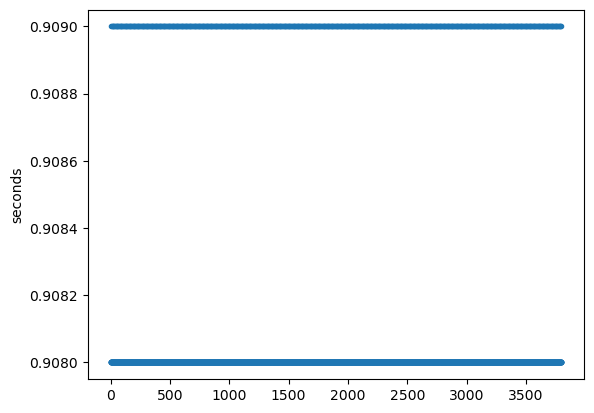

In [21]:
plt.plot(cadence[1:],'.')
plt.ylabel('seconds')
print(np.mean(cadence[1:]))

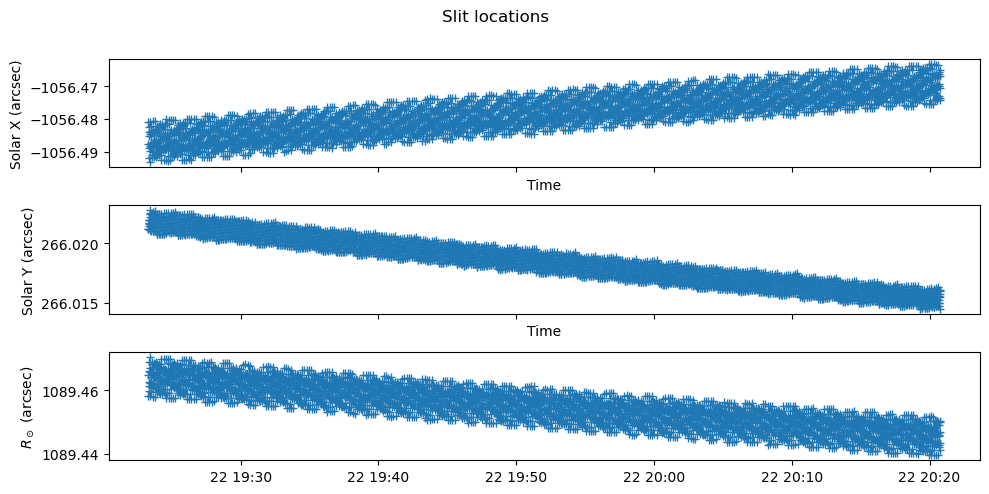

In [87]:
plot_slit_locs(hpxy_coords, time_coords)

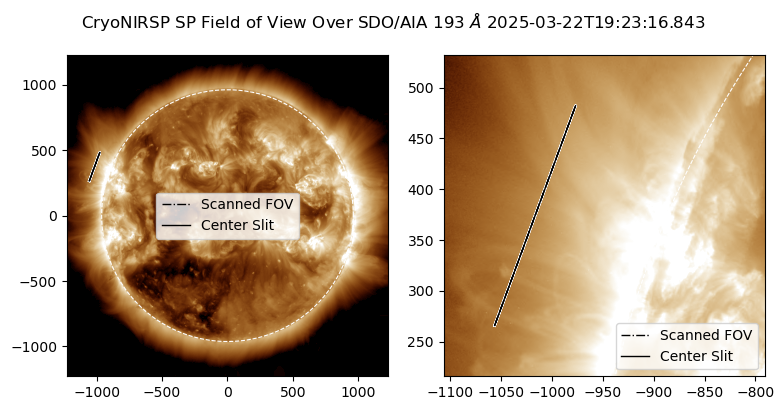

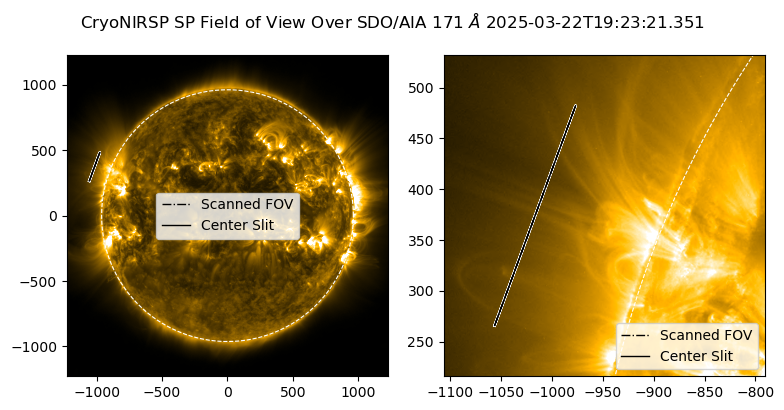

In [88]:
aia_context_plot(hdrs, hpxy_coords, 1, flip_image=True)

Read in the fits files you want to fit. I did it in batches and you can select which batches of files you want to read in and fit. Given there are 3800 exposures in this data set, it may take many hours to fit! 

In [23]:
data, files = get_fits_data(path,file_start=3000)

Getting headers: 100%|██████████████████████| 3800/3800 [00:47<00:00, 79.85it/s]


CNP1DSS =                  0.0 / PriScan1stDirStepSize                          END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

Reading in data: 100%|████████████████████████| 800/800 [00:25<00:00, 31.72it/s]


Here we make use of parallel processing to speed up the fitting of the data.

In [ ]:
wgts = np.ones(data.shape[-1])
wgts[spec_coords > 1076] = 0 
wgts[spec_coords < 1073.5] = 0 


def work(data, spec_coords, wgts, path, file):
    test = fit_data(data, spec_coords)
    res = test.fit_slit(wgts=wgts)
    write_model_results(path, file, res)
    return None

ncpus = 5
tasks = [(dat,spec_coords, wgts, path, file) for dat, file in zip(data[0,0,:],files)]
with ThreadPoolExecutor(max_workers=ncpus) as executor:
        results = list(tqdm(executor.map(work, *zip(*tasks)), total=len(files), desc="Processing"))

Processing:   3%|▉                           | 25/800 [12:09<3:11:15, 14.81s/it]

We can then pull all the fits results into a single array.

In [7]:
from CRYOtools.fit import pull_fit_res

In [68]:
all_res = pull_fit_res(path)

Getting fit data:   0%|          | 0/3800 [00:00<?, ?it/s]

The function returns the results of the fitting and the objective function values when the minimisation finishes.

In [69]:
fit_res, metrics = all_res
fit_res.shape

(10, 3800, 1919)

Examine the quality of the results from the fitting.

From experience, line amplitude and Doppler shift are quite robust parameters. Coronal line width has a much stronger dependence on the value of other 'nuisance' parameters.

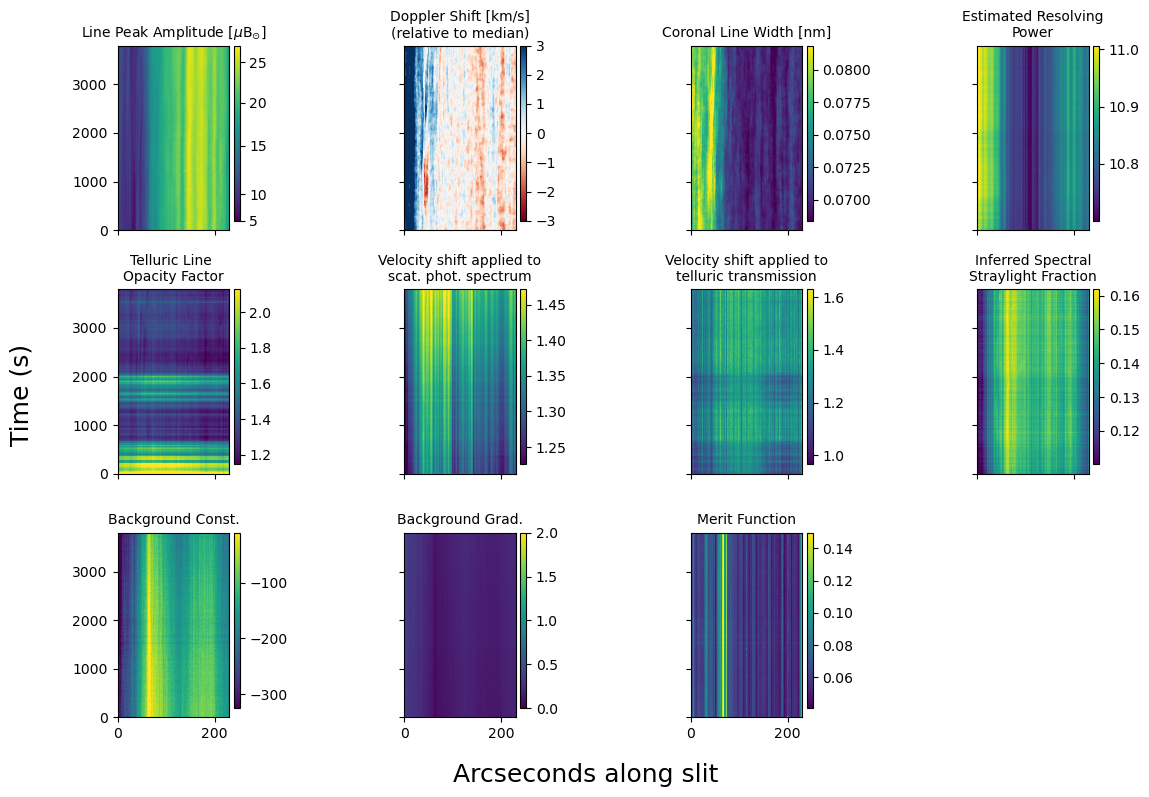

In [22]:
from CRYOtools.plotting import plot_all_params_ss

plot_all_params_ss(fit_res, metrics, spec_coords, hpxy_coords, hdrs, 1)